<a href="https://colab.research.google.com/github/bhanuprakash227/DataScience_ExcelR_Assignments/blob/main/11_Decision__Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Decision Tree**

##**Objective:**
The objective of this assignment is to apply Decision Tree Classification to a given dataset, analyse the performance of the model, and interpret the results.


**Data Preparation**

In [10]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,classification_report,confusion_matrix
df=pd.read_excel("heart_disease.xlsx",sheet_name="Heart_disease")
print("Dataset Shape:",df.shape)
print("\nFirst 5 Rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nSummary Statistics:")
print(df.describe(include="all"))

Dataset Shape: (908, 13)

First 5 Rows:
   age   sex               cp  trestbps  chol    fbs         restecg  thalch  \
0   63  Male   typical angina       145   233   True  lv hypertrophy     150   
1   41  Male  atypical angina       135   203  False          normal     132   
2   57  Male     asymptomatic       140   192  False          normal     148   
3   52  Male   typical angina       118   186  False  lv hypertrophy     190   
4   57  Male     asymptomatic       110   201  False          normal     126   

   exang  oldpeak        slope          thal  num  
0  False      2.3  downsloping  fixed defect    0  
1  False      0.0         flat  fixed defect    0  
2  False      0.4         flat  fixed defect    0  
3  False      0.0         flat  fixed defect    0  
4   True      1.5         flat  fixed defect    0  

Data Types:
age           int64
sex          object
cp           object
trestbps      int64
chol          int64
fbs            bool
restecg      object
thalch        

**Exploratory Data Analysis**

Missing Values:
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

Duplicate Rows: 1

Target Distribution:
num
0    399
1    265
2    109
3    107
4     28
Name: count, dtype: int64


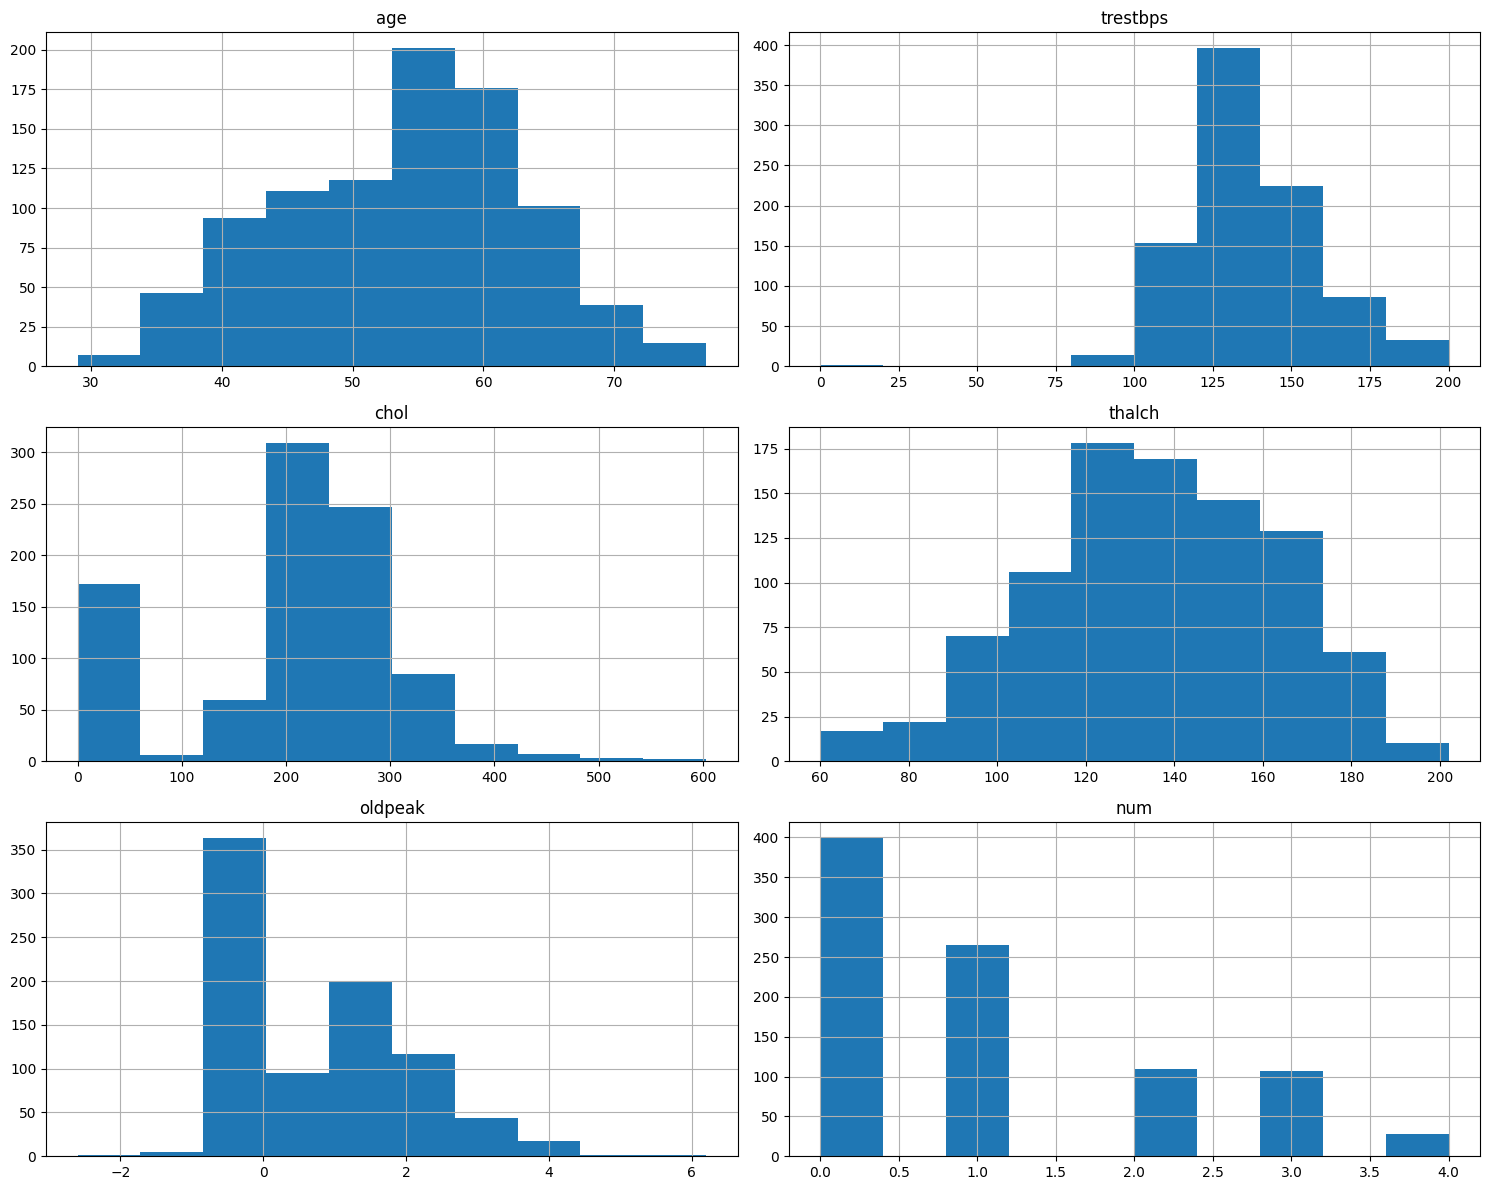

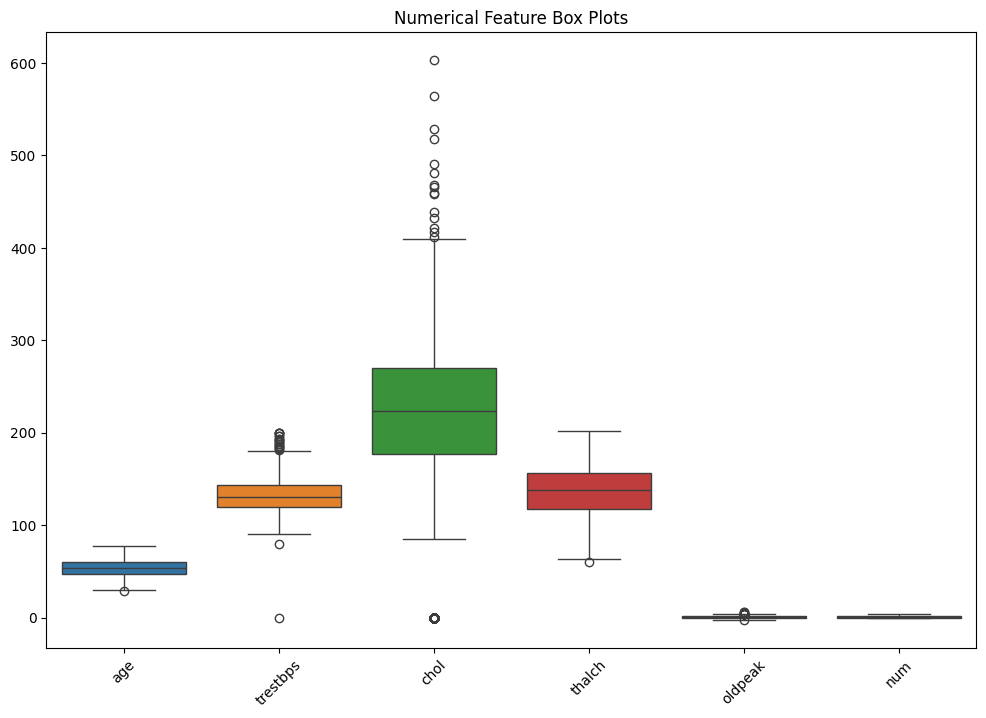

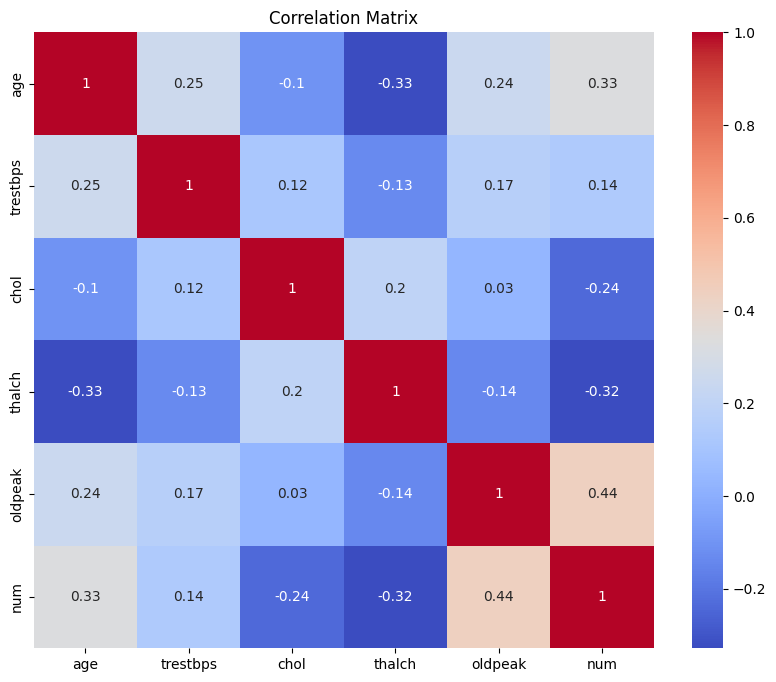

In [11]:

print("Missing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:",df.duplicated().sum())
print("\nTarget Distribution:")
print(df["num"].value_counts().sort_index())
numeric_cols=df.select_dtypes(include=np.number).columns
df[numeric_cols].hist(figsize=(15,12))
plt.tight_layout()
plt.show()
plt.figure(figsize=(12,8))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.title("Numerical Feature Box Plots")
plt.show()
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

**Feature Engineering**

In [12]:

df=df.copy()
numeric_cols=df.select_dtypes(include=np.number).columns.drop("num")
categorical_cols=df.select_dtypes(include=["object"]).columns
for col in numeric_cols:
    df[col]=df[col].fillna(df[col].median())
for col in categorical_cols:
    df[col]=df[col].fillna(df[col].mode()[0])
X=df.drop(columns=["num"])
y=df["num"]
print("Categorical Features:",categorical_cols.tolist())
print("Numerical Features:",numeric_cols.tolist())
print("\nMissing Values After Handling:")
print(X.isnull().sum())

Categorical Features: ['sex', 'cp', 'restecg', 'exang', 'slope', 'thal']
Numerical Features: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

Missing Values After Handling:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
dtype: int64


**Data Preprocessing and Train-Test Split**

In [13]:

X[categorical_cols] = X[categorical_cols].astype(str)
preprocessor = ColumnTransformer([("num", StandardScaler(), numeric_cols), ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
model = Pipeline([("preprocessor", preprocessor), ("classifier", DecisionTreeClassifier(random_state=42))])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Training Samples: 726
Testing Samples: 182

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.65      0.71        80
           1       0.38      0.40      0.39        53
           2       0.17      0.23      0.20        22
           3       0.24      0.29      0.26        21
           4       0.17      0.17      0.17         6

    accuracy                           0.47       182
   macro avg       0.35      0.35      0.34       182
weighted avg       0.51      0.47      0.48       182



**Decision Tree Classification**

In [14]:

accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred,average="weighted",zero_division=0)
recall=recall_score(y_test,y_pred,average="weighted",zero_division=0)
f1=f1_score(y_test,y_pred,average="weighted",zero_division=0)
roc_auc=roc_auc_score(y_test,y_prob,multi_class="ovr",average="weighted")
print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1-Score:",f1)
print("ROC-AUC:",roc_auc)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test,y_pred))

Accuracy: 0.46703296703296704
Precision: 0.5063682380409092
Recall: 0.46703296703296704
F1-Score: 0.4835260270695314
ROC-AUC: 0.6464768858641904

Confusion Matrix:
[[52 16  5  7  0]
 [ 8 21 13  8  3]
 [ 6  9  5  2  0]
 [ 1  8  4  6  2]
 [ 0  1  2  2  1]]


**Hyperparameter Tuning**

In [15]:

parameter_grid={"classifier__max_depth":[3,5,7,10,None],"classifier__min_samples_split":[2,5,10,20],"classifier__criterion":["gini","entropy","log_loss"]}
grid_search=GridSearchCV(model,parameter_grid,cv=5,scoring="accuracy",n_jobs=-1)
grid_search.fit(X_train,y_train)
best_model=grid_search.best_estimator_
best_pred=best_model.predict(X_test)
best_prob=best_model.predict_proba(X_test)
print("Best Parameters:",grid_search.best_params_)
print("Best Cross-Validation Accuracy:",grid_search.best_score_)
print("\nTuned Model Accuracy:",accuracy_score(y_test,best_pred))
print("Tuned Model Precision:",precision_score(y_test,best_pred,average="weighted",zero_division=0))
print("Tuned Model Recall:",recall_score(y_test,best_pred,average="weighted",zero_division=0))
print("Tuned Model F1-Score:",f1_score(y_test,best_pred,average="weighted",zero_division=0))
print("Tuned Model ROC-AUC:",roc_auc_score(y_test,best_prob,multi_class="ovr",average="weighted"))

Best Parameters: {'classifier__criterion': 'gini', 'classifier__max_depth': 3, 'classifier__min_samples_split': 2}
Best Cross-Validation Accuracy: 0.5674728389230042

Tuned Model Accuracy: 0.510989010989011
Tuned Model Precision: 0.4312322598036884
Tuned Model Recall: 0.510989010989011
Tuned Model F1-Score: 0.4670376964231712
Tuned Model ROC-AUC: 0.7518115706963914


**Decision Tree Visualization and Feature Importance**

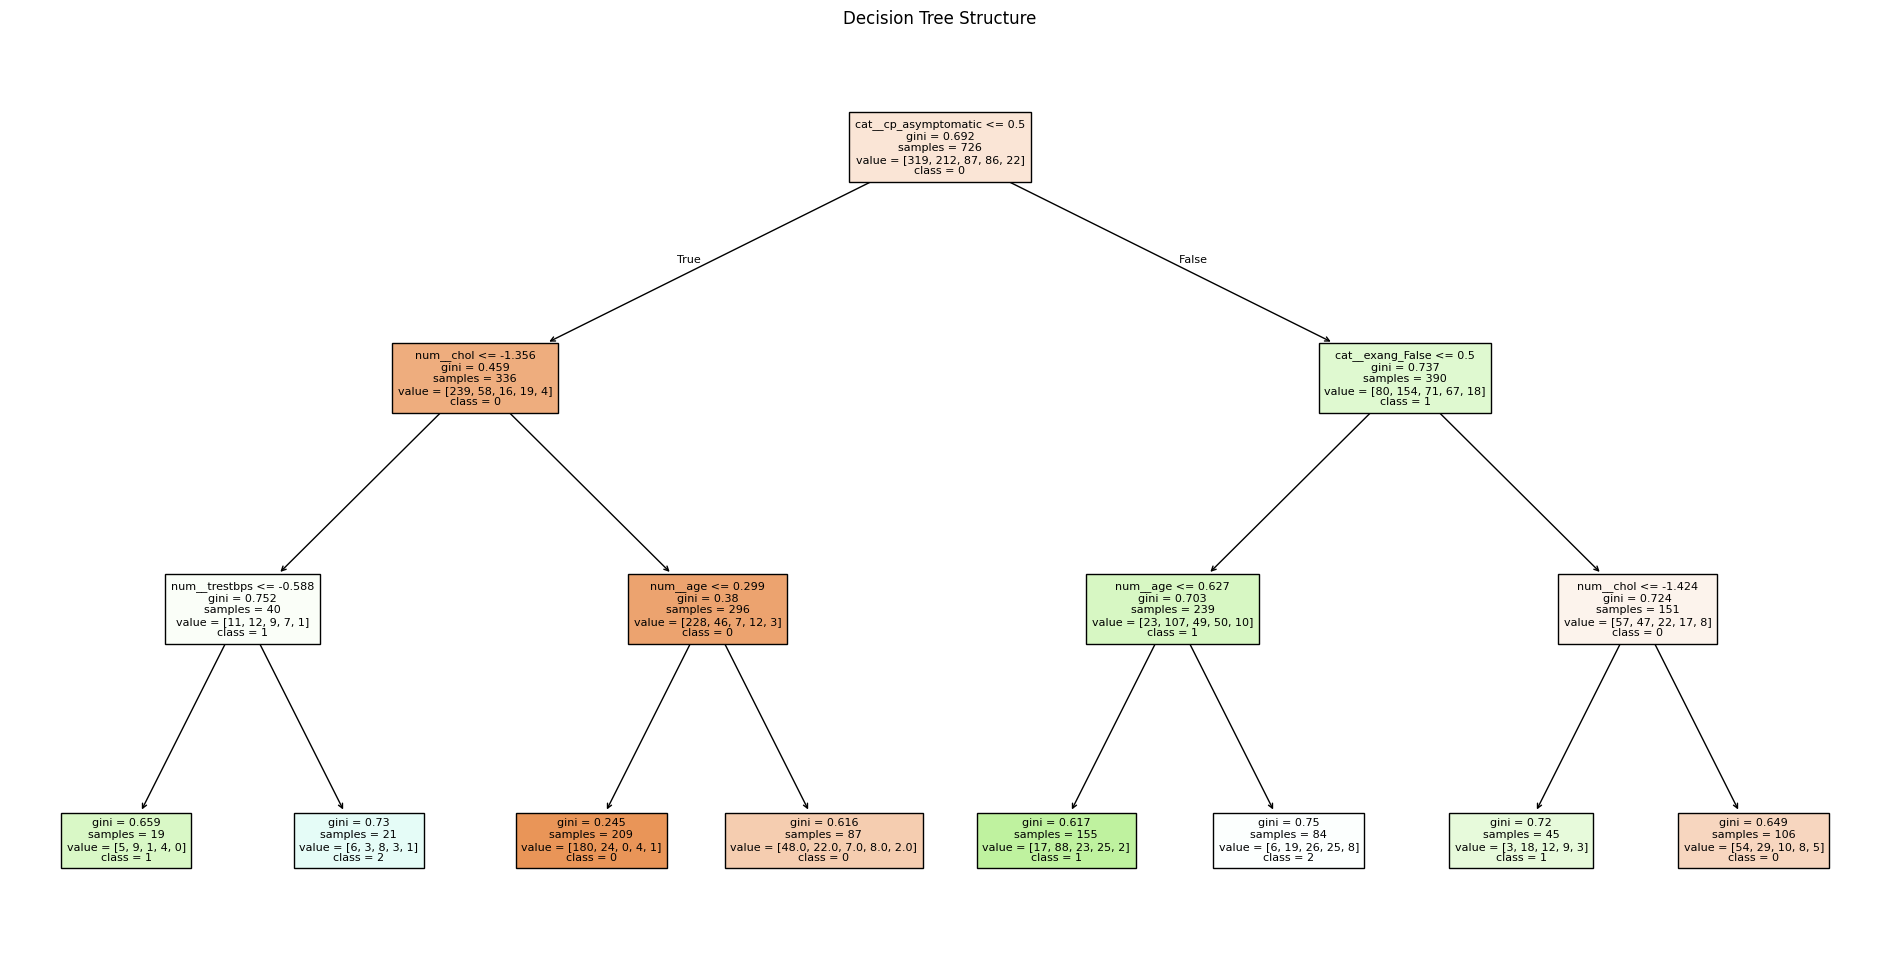

Feature Importance:
                          Feature  Importance
7            cat__cp_asymptomatic    0.554148
2                       num__chol    0.177880
0                        num__age    0.154627
15               cat__exang_False    0.093004
1                   num__trestbps    0.020341
3                     num__thalch    0.000000
5                 cat__sex_Female    0.000000
4                    num__oldpeak    0.000000
6                   cat__sex_Male    0.000000
8         cat__cp_atypical angina    0.000000
10         cat__cp_typical angina    0.000000
9             cat__cp_non-anginal    0.000000
11    cat__restecg_lv hypertrophy    0.000000
12            cat__restecg_normal    0.000000
13  cat__restecg_st-t abnormality    0.000000


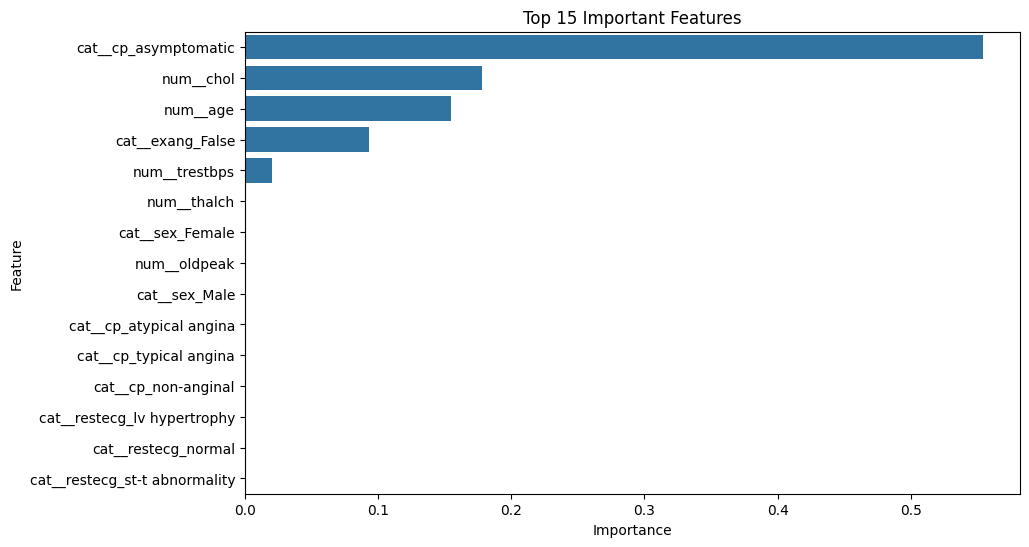

In [16]:

tree_model=best_model.named_steps["classifier"]
feature_names=best_model.named_steps["preprocessor"].get_feature_names_out()
plt.figure(figsize=(24,12))
plot_tree(tree_model,feature_names=feature_names,class_names=[str(c) for c in sorted(y.unique())],filled=True,max_depth=3,fontsize=8)
plt.title("Decision Tree Structure")
plt.show()
importance_df=pd.DataFrame({"Feature":feature_names,"Importance":tree_model.feature_importances_})
importance_df=importance_df.sort_values("Importance",ascending=False)
print("Feature Importance:")
print(importance_df.head(15))
plt.figure(figsize=(10,6))
sns.barplot(data=importance_df.head(15),x="Importance",y="Feature")
plt.title("Top 15 Important Features")
plt.show()

#**Decision Tree Interview Questions**

**1. What are the common hyperparameters in a Decision Tree and how do they affect the model?**

Common hyperparameters include max_depth, min_samples_split, and criterion. max_depth controls the maximum depth of the tree and helps prevent overfitting. min_samples_split specifies the minimum number of samples required to split an internal node. criterion determines how the quality of a split is measured, such as Gini impurity or entropy.

**2. What is the difference between Label Encoding and One-Hot Encoding?**

**Label Encoding** converts categories into numerical values such as 0, 1, 2, etc. It uses fewer columns but may introduce an artificial order between categories.

**One-Hot Encoding** creates separate binary columns for each category. It does not introduce an artificial order, but it can create many columns when there are many categories.